In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# Configure matplotlib inline display and formatting
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

---
## 17.2 Series
A `Series` is a one-dimensional array-like object containing an array of data and an associated array of data labels, called its *index*.

### Example 1: Creating a Series
We begin by creating a series of four random observations with a name attribute.

In [53]:
np.random.seed(42)  # For reproducible random observations
s = pd.Series(np.random.randn(4), name='daily returns')
s

0    0.5
1   -0.1
2    0.6
3    1.5
Name: daily returns, dtype: float64

### Example 2: Arithmetic Operations on Series
Pandas Series support element-wise scalar arithmetic, similar to NumPy arrays.

In [54]:
s * 100

0     49.7
1    -13.8
2     64.8
3    152.3
Name: daily returns, dtype: float64

### Example 3: Applying NumPy Functions to Series
NumPy universal functions (ufuncs) such as `np.abs()` can be applied directly to a Pandas Series.

In [55]:
np.abs(s)

0    0.5
1    0.1
2    0.6
3    1.5
Name: daily returns, dtype: float64

### Example 4: Descriptive Statistics with `s.describe()`
Series provide convenient statistical summary methods such as `.describe()`.

In [56]:
s.describe()

count    4.0
mean     0.6
std      0.7
min     -0.1
25%      0.3
50%      0.6
75%      0.9
max      1.5
Name: daily returns, dtype: float64

### Example 5: Custom Index Assignment
Unlike NumPy arrays, Pandas Series allow custom label-based indices, such as stock ticker symbols.

In [57]:
s.index = ['AMZN', 'AAPL', 'MSFT', 'GOOG']
s

AMZN    0.5
AAPL   -0.1
MSFT    0.6
GOOG    1.5
Name: daily returns, dtype: float64

### Example 6: Dictionary-Style Access and In-Place Assignment
Series support dictionary-like key lookup, item access, and value modification.

In [58]:
print("Value for AMZN:", s['AMZN'])
s['AMZN'] = 0
s

Value for AMZN: 0.4967141530112327


AMZN    0.0
AAPL   -0.1
MSFT    0.6
GOOG    1.5
Name: daily returns, dtype: float64

### Example 7: Membership Test with `in` Operator
We can check if an index label exists in a Series using the standard Python `in` keyword.

In [59]:
'AAPL' in s

True

---
## 17.3 DataFrames
A `DataFrame` is a two-dimensional tabular data structure with labeled axes (rows and columns).
We load data from the Penn World Tables (`test_pwt.csv`).

### Example 8: Loading CSV Data into a DataFrame
We read the Penn World Tables data from a URL using `pd.read_csv()` (with fallback to local file if offline).

In [60]:
# Primary source URL from QuantEcon repository with local fallback
url = 'https://raw.githubusercontent.com/QuantEcon/lecture-source-py/master/source/_static/lecture_specific/pandas/data/test_pwt.csv'
try:
    df = pd.read_csv(url)
except Exception:
    # Fallback to local copy if network is unavailable
    df = pd.read_csv('test_pwt.csv')

type(df)

pandas.DataFrame

### Example 9: Displaying the DataFrame
Inspect the full contents of `df`.

In [61]:
df

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,3.7e+04,1.0,3.0e+05,75.7,5.6
1,Australia,AUS,2000,1.9e+04,1.7,5.4e+05,67.8,6.7
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,14.1
3,Israel,ISR,2000,6.1e+03,4.1,1.3e+05,64.4,10.3
4,Malawi,MWI,2000,1.2e+04,59.5,5.0e+03,74.7,11.7
5,South Africa,ZAF,2000,4.5e+04,6.9,2.3e+05,72.7,5.7
6,United States,USA,2000,2.8e+05,1.0,9.9e+06,72.3,6.0
7,Uruguay,URY,2000,3.2e+03,12.1,2.5e+04,79.0,5.1


---
### 17.3.1 Select Data by Position
Methods for slicing and indexing rows and columns by integer positions.

### Example 10: Row Slicing by Integer Position
Select particular rows using standard Python array slicing notation (`df[2:5]`).

In [62]:
df[2:5]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,14.1
3,Israel,ISR,2000,6.1e+03,4.1,1.3e+05,64.4,10.3
4,Malawi,MWI,2000,1.2e+04,59.5,5.0e+03,74.7,11.7


### Example 11: Column Selection by Column Name List
Select columns by passing a list of column names represented as strings.

In [63]:
df[['country', 'tcgdp']]

,country,tcgdp
0,Argentina,3.0e+05
1,Australia,5.4e+05
2,India,1.7e+06
3,Israel,1.3e+05
4,Malawi,5.0e+03
5,South Africa,2.3e+05
6,United States,9.9e+06
7,Uruguay,2.5e+04


### Example 12: Integer-Based Row and Column Selection with `.iloc`
Select both rows and columns using integer indices with the format `.iloc[rows, columns]`.

In [64]:
df.iloc[2:5, 0:4]

,country,country isocode,year,POP
2,India,IND,2000,1.0e+06
3,Israel,ISR,2000,6.1e+03
4,Malawi,MWI,2000,1.2e+04


### Example 13: Mixed Row and Column Indexing with `.loc`
Select rows and columns using a mixture of integer row indices and column label names.

In [65]:
df.loc[df.index[2:5], ['country', 'tcgdp']]

,country,tcgdp
2,India,1.7e+06
3,Israel,1.3e+05
4,Malawi,5.0e+03


---
### 17.3.2 Select Data by Conditions
Filtering and querying DataFrames using boolean masks, compound conditions, and `.query()`.

### Example 14: Filtering Rows with Boolean Condition
Filter rows where population is greater than or equal to 20,000 using the `[]` operator.

In [66]:
df[df.POP >= 20000]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,3.7e+04,1.0,3.0e+05,75.7,5.6
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,14.1
5,South Africa,ZAF,2000,4.5e+04,6.9,2.3e+05,72.7,5.7
6,United States,USA,2000,2.8e+05,1.0,9.9e+06,72.3,6.0


### Example 15: Evaluating the Boolean Condition Series
Inspect the underlying Series of boolean values generated by `df.POP >= 20000`.

In [67]:
df.POP >= 20000

0     True
1    False
2     True
3    False
4    False
5     True
6     True
7    False
Name: POP, dtype: bool

### Example 16: Compound Filtering with `.isin()` and Bitwise AND (`&`)
Filter rows matching specific countries and having a population greater than 40,000.

In [68]:
df[(df.country.isin(['Argentina', 'India', 'South Africa'])) & (df.POP > 40000)]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,14.1
5,South Africa,ZAF,2000,4.5e+04,6.9,2.3e+05,72.7,5.7


### Example 17: Querying Rows with `df.query()`
The `.query()` method provides a clean, concise string syntax for filtering.

In [69]:
# Equivalent to df[df.POP >= 20000]
df.query("POP >= 20000")

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,3.7e+04,1.0,3.0e+05,75.7,5.6
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,14.1
5,South Africa,ZAF,2000,4.5e+04,6.9,2.3e+05,72.7,5.7
6,United States,USA,2000,2.8e+05,1.0,9.9e+06,72.3,6.0


### Example 18: Compound Query with `df.query()`
Combining multiple conditions inside `.query()`.

In [70]:
df.query("country in ['Argentina', 'India', 'South Africa'] and POP > 40000")

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,14.1
5,South Africa,ZAF,2000,4.5e+04,6.9,2.3e+05,72.7,5.7


### Example 19: Column Arithmetic within Boolean Filtering
Perform arithmetic between different columns (`cc + cg >= 80`) combined with population condition.

In [71]:
df[(df.cc + df.cg >= 80) & (df.POP <= 20000)]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
4,Malawi,MWI,2000,11801.5,59.5,5026.2,74.7,11.7
7,Uruguay,URY,2000,3219.8,12.1,25256.0,79.0,5.1


### Example 20: Column Arithmetic with `df.query()`
The same arithmetic condition expressed via `.query()`.

In [72]:
# Equivalent to the boolean filter above
df.query("cc + cg >= 80 & POP <= 20000")

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
4,Malawi,MWI,2000,11801.5,59.5,5026.2,74.7,11.7
7,Uruguay,URY,2000,3219.8,12.1,25256.0,79.0,5.1


### Example 21: Locating Row with Maximum Value
Select the country with the largest household consumption share of GDP (`cc`).

In [73]:
df.loc[df.cc == max(df.cc)]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
7,Uruguay,URY,2000,3219.8,12.1,25256.0,79.0,5.1


### Example 22: Conditional Filtering with Specific Column Selection
Combine conditional row filtering with specific column selection via `.loc[condition, columns]`.

In [74]:
df.loc[(df.cc + df.cg >= 80) & (df.POP <= 20000), ['country', 'year', 'POP']]

,country,year,POP
4,Malawi,2000,11801.5
7,Uruguay,2000,3219.8


### Example 23: Application - Subsetting DataFrame
Extract a subset of columns (`country`, `POP`, `tcgdp`) to reduce memory and focus analysis.

In [75]:
df_subset = df[['country', 'POP', 'tcgdp']]
df_subset

,country,POP,tcgdp
0,Argentina,3.7e+04,3.0e+05
1,Australia,1.9e+04,5.4e+05
2,India,1.0e+06,1.7e+06
3,Israel,6.1e+03,1.3e+05
4,Malawi,1.2e+04,5.0e+03
5,South Africa,4.5e+04,2.3e+05
6,United States,2.8e+05,9.9e+06
7,Uruguay,3.2e+03,2.5e+04


### Example 24: Saving Subset DataFrame to CSV
Save the subset DataFrame to a CSV file for further analysis.

In [76]:
df_subset.to_csv('pwt_subset.csv', index=False)
print("Saved pwt_subset.csv successfully.")

Saved pwt_subset.csv successfully.


---
### 17.3.3 Apply Method
Using `df.apply()` to apply functions across rows (`axis=1`) or columns (`axis=0`).

### Example 25: Applying Built-in `max` Function across Columns
Apply the built-in `max` function to each numeric column (`axis=0`, default).

In [77]:
df[['year', 'POP', 'XRAT', 'tcgdp', 'cc', 'cg']].apply(max)

year     2.0e+03
POP      1.0e+06
XRAT     6.0e+01
tcgdp    9.9e+06
cc       7.9e+01
cg       1.4e+01
dtype: float64

### Example 26: Applying Lambda Row Identity along `axis=1`
Apply a lambda function to each row (`axis=1`).

In [78]:
df.apply(lambda row: row, axis=1)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,3.7e+04,1.0,3.0e+05,75.7,5.6
1,Australia,AUS,2000,1.9e+04,1.7,5.4e+05,67.8,6.7
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,14.1
3,Israel,ISR,2000,6.1e+03,4.1,1.3e+05,64.4,10.3
4,Malawi,MWI,2000,1.2e+04,59.5,5.0e+03,74.7,11.7
5,South Africa,ZAF,2000,4.5e+04,6.9,2.3e+05,72.7,5.7
6,United States,USA,2000,2.8e+05,1.0,9.9e+06,72.3,6.0
7,Uruguay,URY,2000,3.2e+03,12.1,2.5e+04,79.0,5.1


### Example 27: Constructing a Complex Condition with `df.apply()`
Define a complex conditional expression across rows using `df.apply(..., axis=1)` paired with selected column labels.

In [79]:
complexCondition = df.apply(
    lambda row: row.POP > 40000 if row.country in ['Argentina', 'India', 'South Africa'] else row.POP < 20000,
    axis=1), ['country', 'year', 'POP', 'XRAT', 'tcgdp']
complexCondition

(0    False
 1     True
 2     True
 3     True
 4     True
 5     True
 6    False
 7     True
 dtype: bool,
 ['country', 'year', 'POP', 'XRAT', 'tcgdp'])

### Example 28: Applying the Complex Condition to `df.loc`
Pass the `complexCondition` tuple into `df.loc` to filter rows and select columns simultaneously.

In [80]:
df.loc[complexCondition]

,country,year,POP,XRAT,tcgdp
1,Australia,2000,1.9e+04,1.7,5.4e+05
2,India,2000,1.0e+06,44.9,1.7e+06
3,Israel,2000,6.1e+03,4.1,1.3e+05
4,Malawi,2000,1.2e+04,59.5,5.0e+03
5,South Africa,2000,4.5e+04,6.9,2.3e+05
7,Uruguay,2000,3.2e+03,12.1,2.5e+04


---
### 17.3.4 Make Changes in DataFrames
Modifying values, handling missing data, masking with `.where()`, and element-wise mapping with `.map()`.

### Example 29: Conditional Masking with `df.where()`
Keep rows meeting a condition (`df.POP >= 20000`) and replace non-matching rows with `NaN`.

In [81]:
df.where(df.POP >= 20000)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000.0,3.7e+04,1.0,3.0e+05,75.7,5.6
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,India,IND,2000.0,1.0e+06,44.9,1.7e+06,64.6,14.1
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,South Africa,ZAF,2000.0,4.5e+04,6.9,2.3e+05,72.7,5.7
6,United States,USA,2000.0,2.8e+05,1.0,9.9e+06,72.3,6.0
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Example 30: Modifying Values In-Place with `.loc`
Assign `NaN` to the `cg` column for the observation with the maximum `cg` value.

In [82]:
df.loc[df.cg == max(df.cg), 'cg'] = np.nan
df

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,3.7e+04,1.0,3.0e+05,75.7,5.6
1,Australia,AUS,2000,1.9e+04,1.7,5.4e+05,67.8,6.7
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,NaN
3,Israel,ISR,2000,6.1e+03,4.1,1.3e+05,64.4,10.3
4,Malawi,MWI,2000,1.2e+04,59.5,5.0e+03,74.7,11.7
5,South Africa,ZAF,2000,4.5e+04,6.9,2.3e+05,72.7,5.7
6,United States,USA,2000,2.8e+05,1.0,9.9e+06,72.3,6.0
7,Uruguay,URY,2000,3.2e+03,12.1,2.5e+04,79.0,5.1


### Example 31: Modifying Rows with a Custom Function and `.apply(axis=1)`
Define a custom row updater function to adjust `POP` and `XRAT` values.

In [83]:
def update_row(row):
    # modify POP
    row.POP = np.nan if row.POP <= 10000 else row.POP
    # modify XRAT
    row.XRAT = row.XRAT / 10
    return row

df.apply(update_row, axis=1)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,3.7e+04,1.0e-01,3.0e+05,75.7,5.6
1,Australia,AUS,2000,1.9e+04,1.7e-01,5.4e+05,67.8,6.7
2,India,IND,2000,1.0e+06,4.5e+00,1.7e+06,64.6,NaN
3,Israel,ISR,2000,NaN,4.1e-01,1.3e+05,64.4,10.3
4,Malawi,MWI,2000,1.2e+04,6.0e+00,5.0e+03,74.7,11.7
5,South Africa,ZAF,2000,4.5e+04,6.9e-01,2.3e+05,72.7,5.7
6,United States,USA,2000,2.8e+05,1.0e-01,9.9e+06,72.3,6.0
7,Uruguay,URY,2000,NaN,1.2e+00,2.5e+04,79.0,5.1


### Example 32: Element-Wise Formatting with `df.map()`
Round all numeric entries in the DataFrame to 2 decimal places while leaving strings untouched.

In [84]:
# Round all decimal numbers to 2 decimal places
df.map(lambda x: round(x, 2) if type(x) != str else x)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,3.7e+04,1.0,3.0e+05,75.7,5.6
1,Australia,AUS,2000,1.9e+04,1.7,5.4e+05,67.8,6.7
2,India,IND,2000,1.0e+06,44.9,1.7e+06,64.6,NaN
3,Israel,ISR,2000,6.1e+03,4.1,1.3e+05,64.4,10.3
4,Malawi,MWI,2000,1.2e+04,59.5,5.0e+03,74.7,11.7
5,South Africa,ZAF,2000,4.5e+04,6.9,2.3e+05,72.7,5.7
6,United States,USA,2000,2.8e+05,1.0,9.9e+06,72.3,6.0
7,Uruguay,URY,2000,3.2e+03,12.1,2.5e+04,79.0,5.1


### Example 33: Application - Inserting NaN Values for Imputation Testing
Introduce `NaN` values at specific row and column indices using `zip()` and `.iloc`.

In [85]:
for idx in list(zip([0, 3, 5, 6], [3, 4, 6, 2])):
    df.iloc[idx] = np.nan
df

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000.0,NaN,1.0,3.0e+05,75.7,5.6
1,Australia,AUS,2000.0,1.9e+04,1.7,5.4e+05,67.8,6.7
2,India,IND,2000.0,1.0e+06,44.9,1.7e+06,64.6,NaN
3,Israel,ISR,2000.0,6.1e+03,NaN,1.3e+05,64.4,10.3
4,Malawi,MWI,2000.0,1.2e+04,59.5,5.0e+03,74.7,11.7
5,South Africa,ZAF,2000.0,4.5e+04,6.9,2.3e+05,NaN,5.7
6,United States,USA,NaN,2.8e+05,1.0,9.9e+06,72.3,6.0
7,Uruguay,URY,2000.0,3.2e+03,12.1,2.5e+04,79.0,5.1


### Example 34: Replacing NaNs with 0 using `df.map()`
Define a function to replace any `NaN` values with 0 across the entire DataFrame.

In [86]:
# Replace all NaN values with 0
def replace_nan(x):
    if type(x) != str:
        return 0 if np.isnan(x) else x
    else:
        return x

df.map(replace_nan)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000.0,0.0e+00,1.0,3.0e+05,75.7,5.6
1,Australia,AUS,2000.0,1.9e+04,1.7,5.4e+05,67.8,6.7
2,India,IND,2000.0,1.0e+06,44.9,1.7e+06,64.6,0.0
3,Israel,ISR,2000.0,6.1e+03,0.0,1.3e+05,64.4,10.3
4,Malawi,MWI,2000.0,1.2e+04,59.5,5.0e+03,74.7,11.7
5,South Africa,ZAF,2000.0,4.5e+04,6.9,2.3e+05,0.0,5.7
6,United States,USA,0.0,2.8e+05,1.0,9.9e+06,72.3,6.0
7,Uruguay,URY,2000.0,3.2e+03,12.1,2.5e+04,79.0,5.1


### Example 35: Imputing Missing Values with Column Means using `df.fillna()`
Perform single mean imputation on numeric columns using `.fillna()`.

In [87]:
df = df.fillna(df.iloc[:, 2:8].mean())
df

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000.0,2.0e+05,1.0,3.0e+05,75.7,5.6
1,Australia,AUS,2000.0,1.9e+04,1.7,5.4e+05,67.8,6.7
2,India,IND,2000.0,1.0e+06,44.9,1.7e+06,64.6,7.3
3,Israel,ISR,2000.0,6.1e+03,18.2,1.3e+05,64.4,10.3
4,Malawi,MWI,2000.0,1.2e+04,59.5,5.0e+03,74.7,11.7
5,South Africa,ZAF,2000.0,4.5e+04,6.9,2.3e+05,71.2,5.7
6,United States,USA,2000.0,2.8e+05,1.0,9.9e+06,72.3,6.0
7,Uruguay,URY,2000.0,3.2e+03,12.1,2.5e+04,79.0,5.1


---
### 17.3.5 Standardization and Visualization
Data transformation, index manipulation, column operations, and plotting bar charts.

### Example 36: Extracting Target Columns
Subset the DataFrame down to `country`, `POP`, and `tcgdp`.

In [88]:
df = df[['country', 'POP', 'tcgdp']]
df

,country,POP,tcgdp
0,Argentina,2.0e+05,3.0e+05
1,Australia,1.9e+04,5.4e+05
2,India,1.0e+06,1.7e+06
3,Israel,6.1e+03,1.3e+05
4,Malawi,1.2e+04,5.0e+03
5,South Africa,4.5e+04,2.3e+05
6,United States,2.8e+05,9.9e+06
7,Uruguay,3.2e+03,2.5e+04


### Example 37: Setting the Index to `country`
Set the `country` column as the DataFrame index.

In [89]:
df = df.set_index('country')
df

,POP,tcgdp
country,,
Argentina,2.0e+05,3.0e+05
Australia,1.9e+04,5.4e+05
India,1.0e+06,1.7e+06
Israel,6.1e+03,1.3e+05
Malawi,1.2e+04,5.0e+03
South Africa,4.5e+04,2.3e+05
United States,2.8e+05,9.9e+06
Uruguay,3.2e+03,2.5e+04


### Example 38: Renaming Columns
Rename the columns to more readable descriptive labels: `'population'` and `'total GDP'`.

In [90]:
df.columns = 'population', 'total GDP'
df

,population,total GDP
country,,
Argentina,2.0e+05,3.0e+05
Australia,1.9e+04,5.4e+05
India,1.0e+06,1.7e+06
Israel,6.1e+03,1.3e+05
Malawi,1.2e+04,5.0e+03
South Africa,4.5e+04,2.3e+05
United States,2.8e+05,9.9e+06
Uruguay,3.2e+03,2.5e+04


### Example 39: Rescaling Population Units
Convert the population variable from thousands into single unit counts (`* 1e3`).

In [91]:
df['population'] = df['population'] * 1e3
df

,population,total GDP
country,,
Argentina,2.0e+08,3.0e+05
Australia,1.9e+07,5.4e+05
India,1.0e+09,1.7e+06
Israel,6.1e+06,1.3e+05
Malawi,1.2e+07,5.0e+03
South Africa,4.5e+07,2.3e+05
United States,2.8e+08,9.9e+06
Uruguay,3.2e+06,2.5e+04


### Example 40: Calculating Real GDP Per Capita
Calculate Real GDP per capita in single dollars (`total GDP * 1e6 / population`).

In [92]:
df['GDP percap'] = df['total GDP'] * 1e6 / df['population']
df

,population,total GDP,GDP percap
country,,,
Argentina,2.0e+08,3.0e+05,1503.6
Australia,1.9e+07,5.4e+05,28436.4
India,1.0e+09,1.7e+06,1717.3
Israel,6.1e+06,1.3e+05,21138.7
Malawi,1.2e+07,5.0e+03,425.9
South Africa,4.5e+07,2.3e+05,5042.6
United States,2.8e+08,9.9e+06,35080.4
Uruguay,3.2e+06,2.5e+04,7844.0


### Example 41: Generating a Bar Plot of GDP Per Capita
Create a bar plot of GDP per capita using Pandas' built-in Matplotlib wrapper.

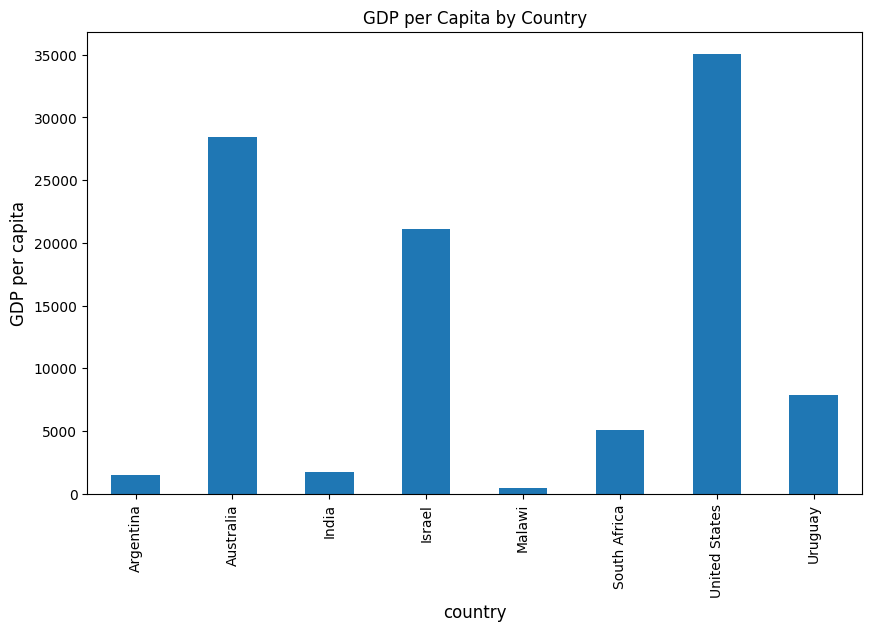

In [93]:
ax = df['GDP percap'].plot(kind='bar')
ax.set_xlabel('country', fontsize=12)
ax.set_ylabel('GDP per capita', fontsize=12)
plt.title('GDP per Capita by Country')
plt.show()

### Example 42: Sorting DataFrame by GDP Per Capita
Sort the DataFrame in descending order by `GDP percap`.

In [94]:
df = df.sort_values(by='GDP percap', ascending=False)
df

,population,total GDP,GDP percap
country,,,
United States,2.8e+08,9.9e+06,35080.4
Australia,1.9e+07,5.4e+05,28436.4
Israel,6.1e+06,1.3e+05,21138.7
Uruguay,3.2e+06,2.5e+04,7844.0
South Africa,4.5e+07,2.3e+05,5042.6
India,1.0e+09,1.7e+06,1717.3
Argentina,2.0e+08,3.0e+05,1503.6
Malawi,1.2e+07,5.0e+03,425.9


### Example 43: Re-Plotting Sorted GDP Per Capita
Re-generate the bar plot after sorting countries from highest to lowest GDP per capita.

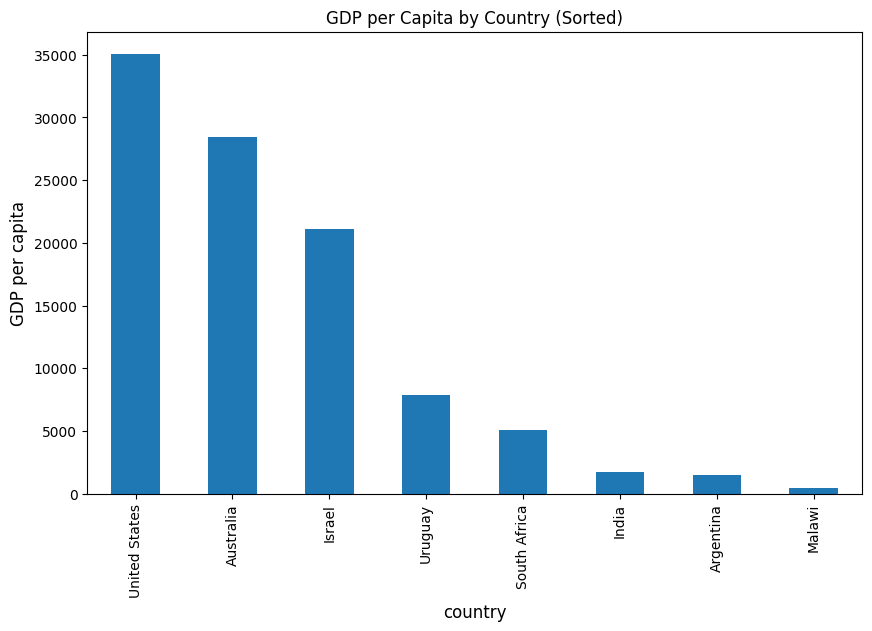

In [95]:
ax = df['GDP percap'].plot(kind='bar')
ax.set_xlabel('country', fontsize=12)
ax.set_ylabel('GDP per capita', fontsize=12)
plt.title('GDP per Capita by Country (Sorted)')
plt.show()

---
## 17.4 On-Line Data Sources
Querying online databases programmatically: Federal Reserve Economic Data (FRED) and World Bank (`wbgapi`).

### 17.4.1 Accessing Data with requests
Accessing FRED data using the `requests` library and parsing into Pandas.

### Example 44: Testing Connection to FRED API with `requests.get`
Fetch the unemployment rate CSV directly from FRED and verify the request status.

In [108]:
fred_url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE'
r = requests.get(fred_url)
print("HTTP Status Code:", r.status_code)

HTTP Status Code: 200


### Example 45: Reading and Inspecting Raw Lines from Response
Inspect the first few raw header and data lines from the FRED CSV response.

In [97]:
url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE'
source = requests.get(url).content.decode().split("\n")
print("Line 0:", source[0])
print("Line 1:", source[1])
print("Line 2:", source[2])

Line 0: observation_date,UNRATE
Line 1: 1948-01-01,3.4
Line 2: 1948-02-01,3.8


### Example 46: Parsing FRED CSV into Pandas DataFrame
Use `pd.read_csv()` with `index_col=0` and `parse_dates=True` to parse dates automatically.

In [98]:
data = pd.read_csv(url, index_col=0, parse_dates=True)
print("Type of data:", type(data))

Type of data: <class 'pandas.DataFrame'>


### Example 47: Inspecting First Rows with `data.head()`
Inspect the top observations of the unemployment dataset.

In [99]:
data.head()  # A useful method to get a quick look at a data frame

,UNRATE
observation_date,
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5


### Example 48: Summary Statistics with `data.describe()`
Configure precision and compute summary statistics for the unemployment rate.

In [100]:
pd.set_option('display.precision', 1)
data.describe()  # Summary statistics

,UNRATE
count,943.0
mean,5.7
std,1.7
min,2.5
25%,4.3
50%,5.5
75%,6.7
max,14.8


### Example 49: Date-Range Slicing and Time Series Plotting
Slice the DataFrame by date range (`'2006':'2012'`) and plot the unemployment rate.

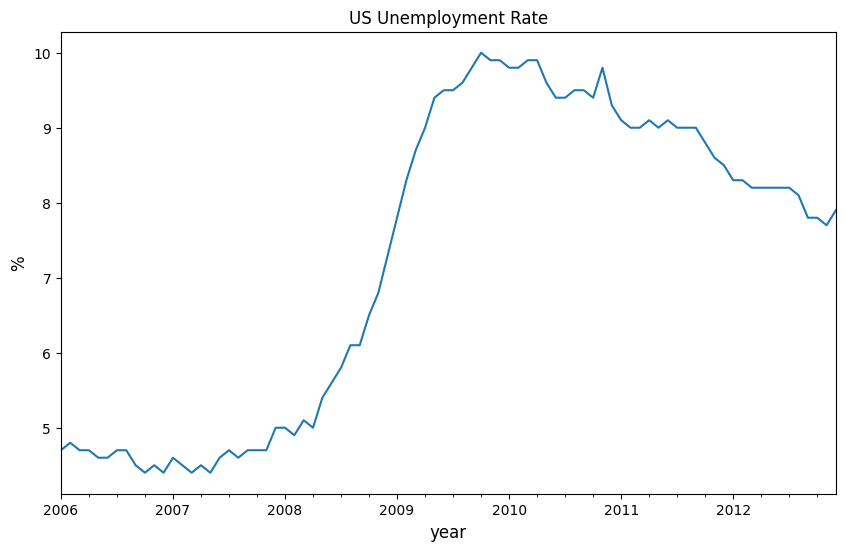

In [101]:
ax = data['2006':'2012'].plot(title='US Unemployment Rate', legend=False)
ax.set_xlabel('year', fontsize=12)
ax.set_ylabel('%', fontsize=12)
plt.show()

---
### 17.4.2 Using wbgapi to Access World Bank Data
The `wbgapi` library queries the World Bank's extensive indicators databases.

### Example 50: Inspecting World Bank Indicator Metadata with `wbgapi`
Query metadata for indicator `GC.DOD.TOTL.GD.ZS` (Central government debt as % of GDP).

In [109]:
import wbgapi as wb

wb.series.info('GC.DOD.TOTL.GD.ZS')

id,value
GC.DOD.TOTL.GD.ZS,"Central government debt, total (% of GDP)"
,1 elements


### Example 51: Fetching World Bank Government Debt Data and Plotting
Retrieve government debt data for the USA and Australia (2005-2015), transpose, and plot.

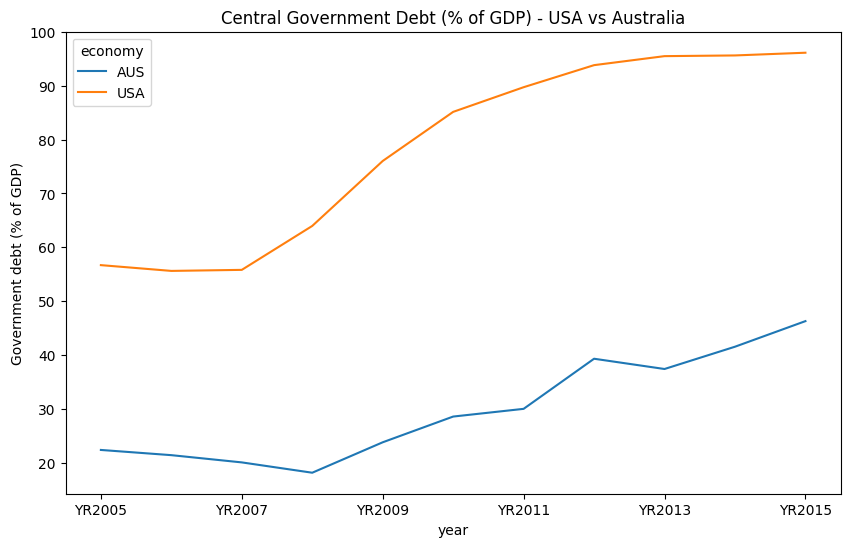

In [ ]:
govt_debt = wb.data.DataFrame('GC.DOD.TOTL.GD.ZS', economy=['USA', 'AUS'], time=range(2005, 2016))
govt_debt = govt_debt.T  # Move years from columns to rows for plotting
ax = govt_debt.plot(xlabel='year', ylabel='Government debt (% of GDP)')
plt.title('Central Government Debt (% of GDP) - USA vs Australia')
plt.show()

---
## 17.5 Exercises
Practical exercises covering Yahoo Finance data retrieval, percentage price change calculations, and multi-asset visualization.

### Exercise 17.5.1: Percentage Price Change over 2021 for Stocks
Calculate and visualize the percentage price change over 2021 for 11 major global stocks using `yfinance`.

### Example 52: Defining `read_data` and Fetching Stock Price Data
Define a helper function to read historical closing prices from Yahoo Finance for a dictionary of tickers.

In [ ]:
import datetime as dt
import yfinance as yf

ticker_list = {
    'INTC': 'Intel',
    'MSFT': 'Microsoft',
    'IBM': 'IBM',
    'BHP': 'BHP',
    'TM': 'Toyota',
    'AAPL': 'Apple',
    'AMZN': 'Amazon',
    'C': 'Citigroup',
    'QCOM': 'Qualcomm',
    'KO': 'Coca-Cola',
    'GOOG': 'Google'
}

def read_data(ticker_list,
              start=dt.datetime(2021, 1, 1),
              end=dt.datetime(2021, 12, 31)):
    """
    This function reads in closing price data from Yahoo
    for each tick in the ticker_list.
    """
    ticker = pd.DataFrame()
    for tick in ticker_list:
        stock = yf.Ticker(tick)
        prices = stock.history(start=start, end=end)
        # Change the index to date-only
        prices.index = pd.to_datetime(prices.index.date)
        closing_prices = prices['Close']
        ticker[tick] = closing_prices
    return ticker

ticker = read_data(ticker_list)
ticker.head()

,INTC,MSFT,IBM,BHP,TM,AAPL,AMZN,C,QCOM,KO,GOOG
2021-01-04,44.9,207.6,94.4,41.5,135.1,125.6,159.3,49.6,131.3,44.5,85.6
2021-01-05,45.8,207.8,96.1,42.8,135.2,127.2,160.9,50.8,134.8,44.0,86.2
2021-01-06,46.2,202.4,98.5,44.2,135.3,122.9,156.9,53.8,133.7,42.6,86.0
2021-01-07,47.2,208.1,98.3,45.1,134.5,127.1,158.1,54.4,137.7,42.2,88.5
2021-01-08,46.7,209.4,97.9,45.3,134.7,128.2,159.1,53.9,138.5,43.1,89.5


### Example 53: Solution 1 - Calculating Percentage Change from First and Last Prices
Extract the first and last prices as Series and compute `(p2 - p1) / p1 * 100`.

In [ ]:
p1 = ticker.iloc[0]   # Get the first set of prices as a Series
p2 = ticker.iloc[-1]  # Get the last set of prices as a Series
price_change = (p2 - p1) / p1 * 100
price_change

INTC     6.9
MSFT    57.2
IBM     18.7
BHP     -2.2
TM      23.4
AAPL    38.6
AMZN     5.8
C        3.6
QCOM    25.3
KO      14.9
GOOG    69.0
dtype: float64

### Example 54: Solution 2 - Alternative Calculation with `.pct_change()`
Use the built-in `.pct_change()` method with `periods=len(ticker)-1` across rows.

In [ ]:
change = ticker.pct_change(periods=len(ticker) - 1, axis='rows') * 100
price_change = change.iloc[-1]
price_change

INTC     6.9
MSFT    57.2
IBM     18.7
BHP     -2.2
TM      23.4
AAPL    38.6
AMZN     5.8
C        3.6
QCOM    25.3
KO      14.9
GOOG    69.0
Name: 2021-12-30 00:00:00, dtype: float64

### Example 55: Plotting Stock Percentage Change as a Bar Chart
Sort the percentage changes, map ticker symbols to company names, and plot as a horizontal/vertical bar chart.

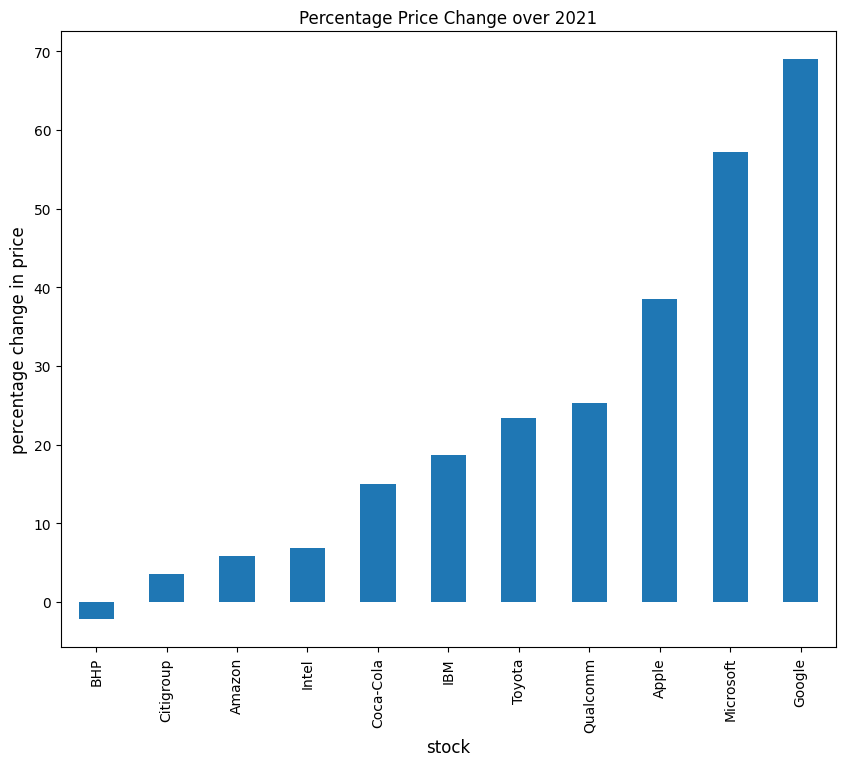

In [ ]:
price_change = price_change.copy()
price_change.sort_values(inplace=True)
price_change.rename(index=ticker_list, inplace=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel('stock', fontsize=12)
ax.set_ylabel('percentage change in price', fontsize=12)
price_change.plot(kind='bar', ax=ax)
plt.title('Percentage Price Change over 2021')
plt.show()

---
### Exercise 17.5.2: Year-on-Year Percentage Change for Indices (1971–2021)
Calculate and visualize the year-on-year percentage return from 1971 to 2021 for four major market indices: S&P 500, NASDAQ, Dow Jones, and Nikkei.

### Example 56: Fetching Historical Market Indices Data (1971–2021)
Query historical closing prices for market indices over the 50-year period using `read_data`.

In [ ]:
indices_list = {
    '^GSPC': 'S&P 500',
    '^IXIC': 'NASDAQ',
    '^DJI': 'Dow Jones',
    '^N225': 'Nikkei'
}

indices_data = read_data(
    indices_list,
    start=dt.datetime(1971, 1, 1),  # Common Start Date
    end=dt.datetime(2021, 12, 31)
)
indices_data.head()

,^GSPC,^IXIC,^DJI,^N225
1971-01-04,91.2,NaN,NaN,NaN
1971-01-05,91.8,NaN,NaN,1989.4
1971-01-06,92.3,NaN,NaN,1981.7
1971-01-07,92.4,NaN,NaN,2001.0
1971-01-08,92.2,NaN,NaN,2040.9


### Example 57: Calculating Yearly Returns using `groupby`
Group prices by year, extract first and last prices per year, and calculate annual returns.

In [ ]:
yearly_returns = pd.DataFrame()
for index, name in indices_list.items():
    p1 = indices_data.groupby(indices_data.index.year)[index].first()  # First price per year
    p2 = indices_data.groupby(indices_data.index.year)[index].last()   # Last price per year
    returns = (p2 - p1) / p1
    yearly_returns[name] = returns

yearly_returns

,S&P 500,NASDAQ,Dow Jones,Nikkei
1971,1.2e-01,1.4e-01,NaN,3.6e-01
1972,1.6e-01,1.8e-01,NaN,9.2e-01
1973,-1.8e-01,-3.2e-01,NaN,-1.8e-01
1974,-3.0e-01,-3.5e-01,NaN,-9.9e-02
1975,2.8e-01,2.8e-01,NaN,1.7e-01
1976,1.8e-01,2.5e-01,NaN,1.3e-01
1977,-1.1e-01,7.5e-02,NaN,-2.7e-02
1978,2.4e-02,1.3e-01,NaN,2.3e-01
1979,1.2e-01,2.8e-01,NaN,8.7e-02
1980,2.8e-01,3.7e-01,NaN,7.7e-02


### Example 58: Summary Statistics with `.describe()`
Display descriptive summary statistics for the yearly returns across all four indices.

In [ ]:
yearly_returns.describe()

,S&P 500,NASDAQ,Dow Jones,Nikkei
count,5.1e+01,5.1e+01,3.0e+01,5.1e+01
mean,9.2e-02,1.3e-01,9.1e-02,7.9e-02
std,1.6e-01,2.5e-01,1.4e-01,2.4e-01
min,-3.8e-01,-4.0e-01,-3.3e-01,-4.0e-01
25%,-2.2e-03,1.6e-04,2.5e-02,-6.8e-02
50%,1.2e-01,1.4e-01,8.9e-02,7.7e-02
75%,2.0e-01,2.8e-01,2.1e-01,2.0e-01
max,3.4e-01,8.4e-01,3.3e-01,9.2e-01


### Example 59: Plotting 2x2 Grid of Subplots for Market Indices
Generate a 2x2 grid of time-series line charts showing annual percentage returns for each index over time.

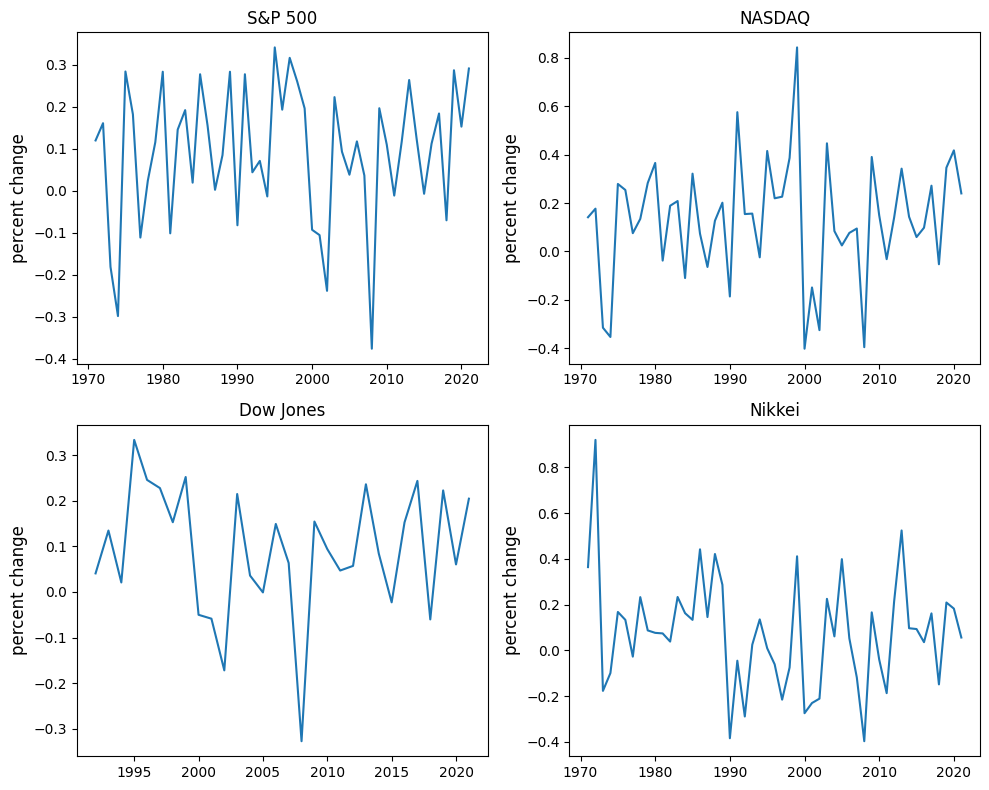

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for iter_, ax in enumerate(axes.flatten()):
    index_name = yearly_returns.columns[iter_]
    ax.plot(yearly_returns[index_name])
    ax.set_ylabel("percent change", fontsize=12)
    ax.set_title(index_name)

plt.tight_layout()
plt.show()